In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
sites = [ "GAGGTAAAC" , "TCCGTAAGC" , "CAGGTTGGA" ,
 "ACAGTCAGC" , "TAGGTCAGC" , "CAGGTCAGC" ,
 "CAGGTCGAT" , "CAGGTCAGC" , "CAGGTCAGC" ,
 "CAGGTTGGC" ]

In [23]:
def build_pfm(sites):
    matrix = np.zeros((4, len(sites[0])))
    mapping = {'A':0, 'C': 1, 'G':2, 'T':3}
    for seq in sites:
        for i, char in enumerate(seq):
            matrix[mapping[char], i] += 1
    return matrix

In [24]:
def build_ppm(pfm, pseudocount=0.1):
    n_seq = np.sum(pfm[:, 0])
    matrix = (pfm + pseudocount)/(n_seq + 4*pseudocount)
    return matrix

In [25]:
pfm = build_pfm(sites)
ppm = build_ppm(pfm)

In [26]:
ppm.shape

(4, 9)

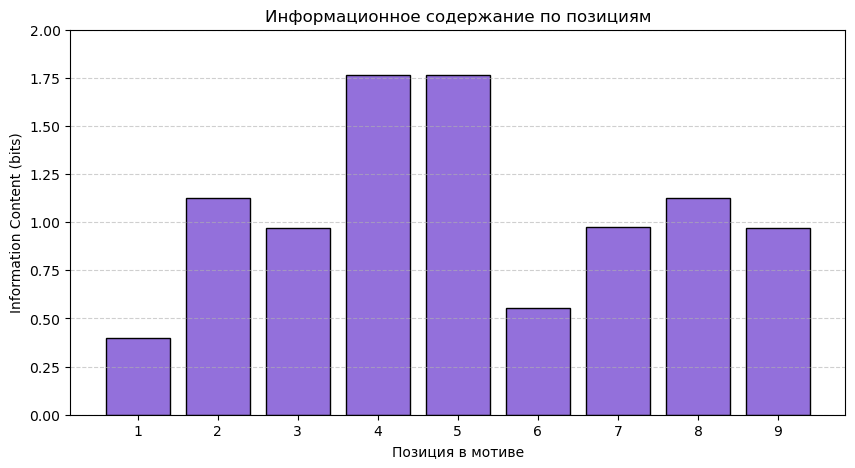

In [ ]:
def calculate_entropy(ppm):
    entropy = -np.sum(ppm * np.log2(ppm), axis=0)
    return entropy

h_values = calculate_entropy(ppm)


ic_values = 2 - h_values

positions = np.arange(1, len(ic_values) + 1)

plt.figure(figsize=(10, 5))
plt.bar(positions, ic_values, color='mediumpurple', edgecolor='black')
plt.xticks(positions)
plt.xlabel('Позиция в мотиве')
plt.ylabel('Information Content (bits)')
plt.title('Информационное содержание по позициям')
plt.ylim(0, 2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [20]:
for site in sites:
    print(site)

GAGGTAAAC
TCCGTAAGC
CAGGTTGGA
ACAGTCAGC
TAGGTCAGC
CAGGTCAGC
CAGGTCGAT
CAGGTCAGC
CAGGTCAGC
CAGGTTGGC


4, 5 - совпадают, даже по выравниваниям видно